Reinitializing model state for SHAP evaluation...
Computing SHAP summary trees...


Rendering Global Summary Plot...


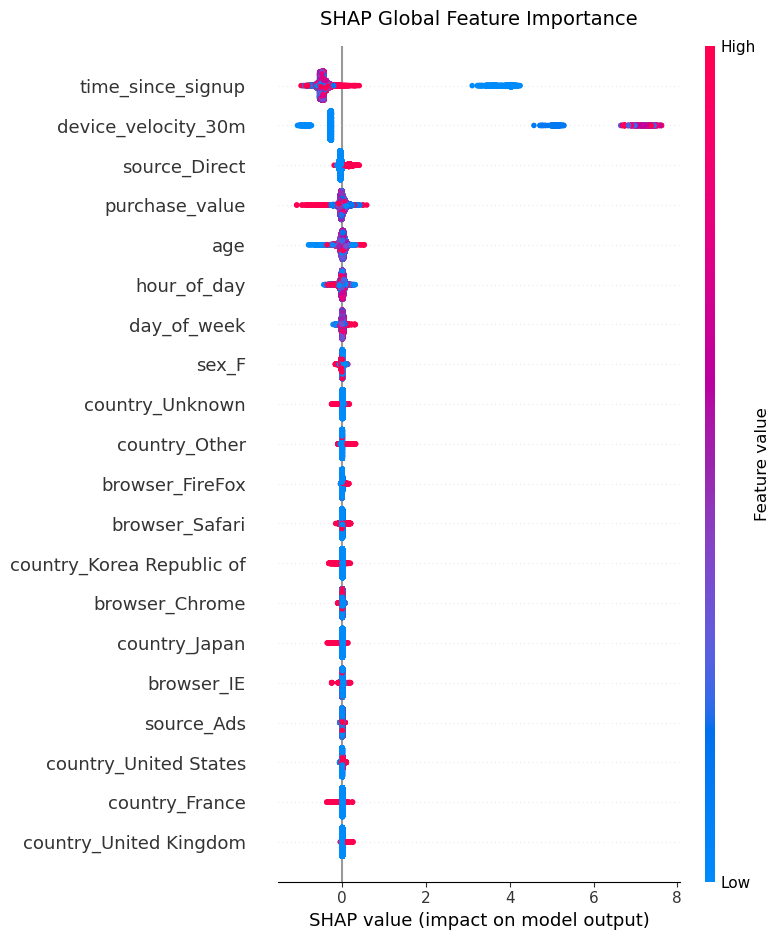

Rendering True Positive Force Plot (Index Row: 17)...


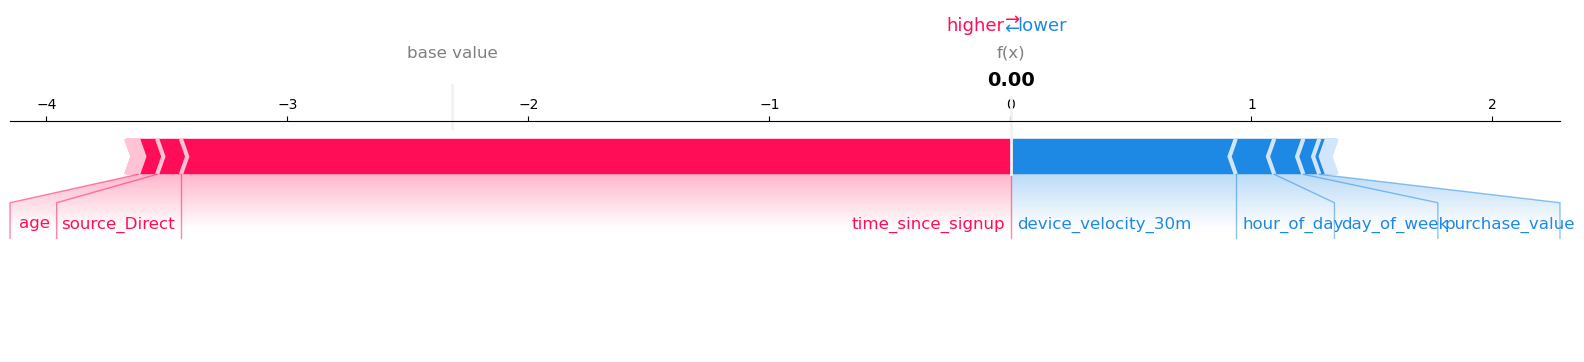

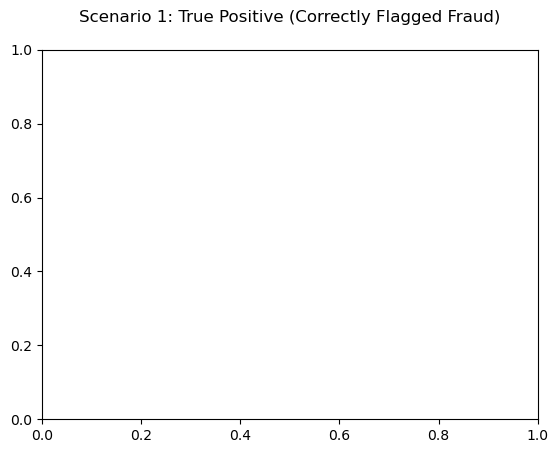

Rendering False Positive Force Plot (Index Row: 795)...


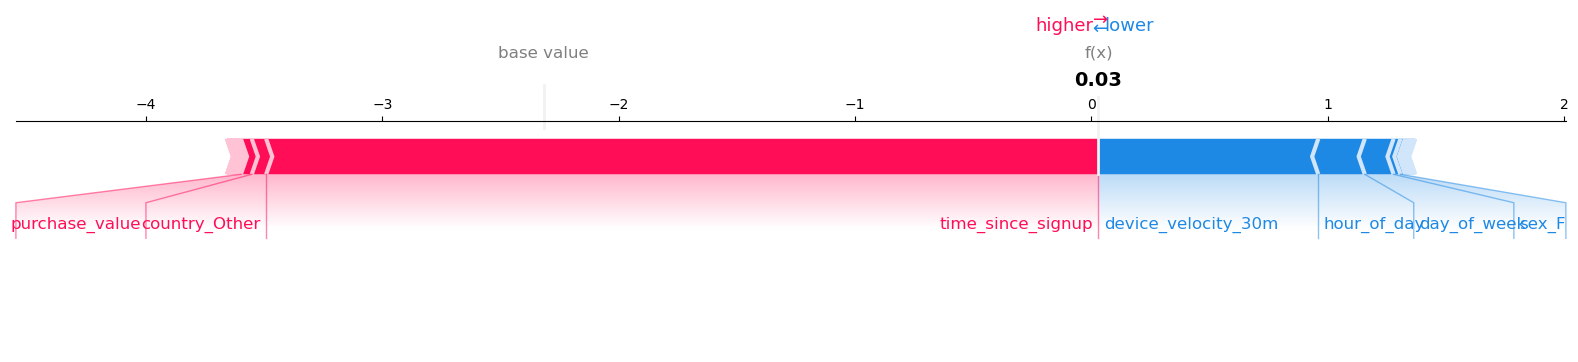

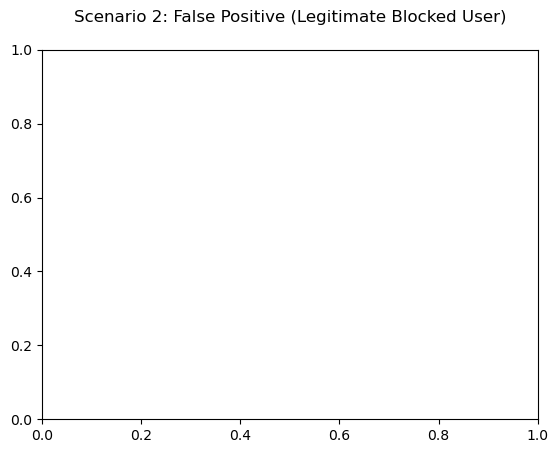

Rendering False Negative Force Plot (Index Row: 2)...


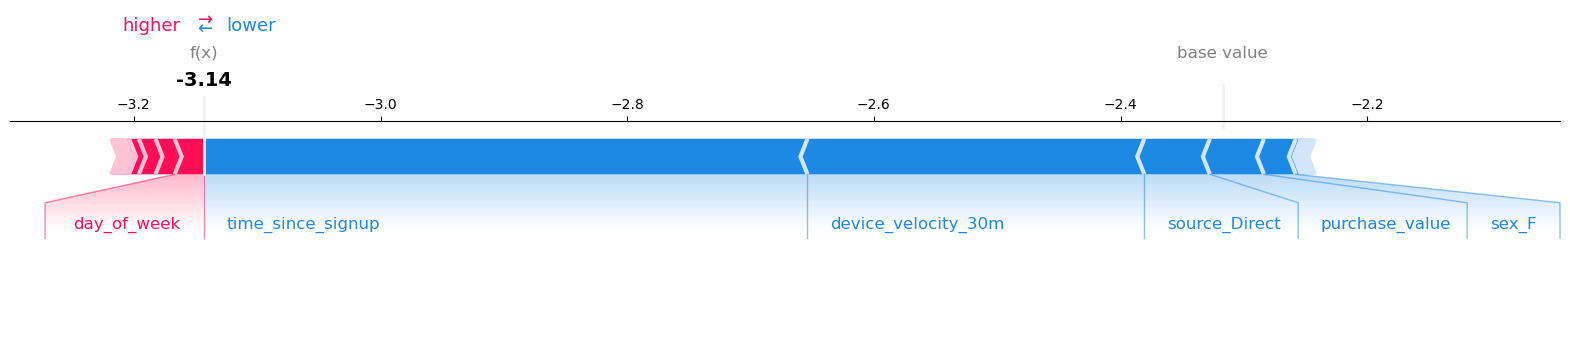

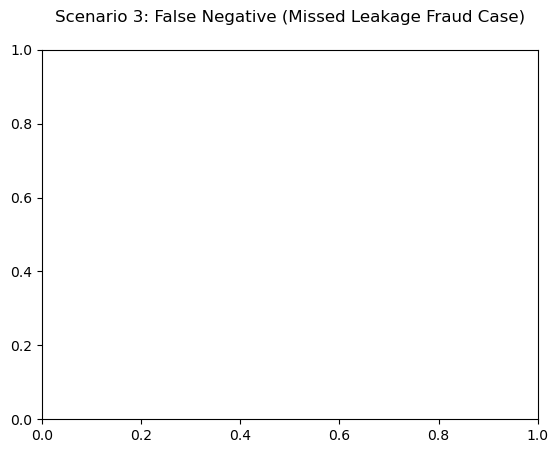

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import xgboost as xgb
import shap
import matplotlib.pyplot as plt

# ==============================================================================
# 1. RELOAD DATA & PIPELINE ENVIRONMENT
# ==============================================================================
print("Reinitializing model state for SHAP evaluation...")
df_fraud = pd.read_csv("../data/processed/fraud_final.csv")

drop_cols = ['class', 'user_id', 'signup_time', 'purchase_time', 'device_id', 'ip_address']
X_f = df_fraud.drop(columns=drop_cols)
y_f = df_fraud["class"]

# Compress country string dimensions into top-15 categories
top_countries = X_f['country'].value_counts().index[:15]
X_f['country'] = X_f['country'].apply(lambda x: x if x in top_countries else 'Other')

num_cols = ['purchase_value', 'age', 'time_since_signup', 'hour_of_day', 'day_of_week', 'device_velocity_30m']
cat_cols = ['source', 'browser', 'sex', 'country']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])

# Create the exact same train/test split as before
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_f, y_f, test_size=0.2, stratify=y_f, random_state=42)

X_train_f_processed = preprocessor.fit_transform(X_train_f)
X_test_f_processed = preprocessor.transform(X_test_f)

# Re-train your winning XGBoost model instance
xgb_fraud = xgb.XGBClassifier(n_estimators=150, max_depth=5, learning_rate=0.1, random_state=42, eval_metric='logloss')
xgb_fraud.fit(X_train_f_processed, y_train_f)

# Extract predictions
y_proba_xgb_f = xgb_fraud.predict_proba(X_test_f_processed)[:, 1]
y_pred_xgb_f = (y_proba_xgb_f >= 0.3).astype(int)

# ==============================================================================
# 2. RUN SHAP EXPLANATIONS
# ==============================================================================
print("Computing SHAP summary trees...")
encoded_cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols)
all_features_list = num_cols + list(encoded_cat_features)

explainer = shap.TreeExplainer(xgb_fraud)
shap_values = explainer(X_test_f_processed)

# Initialize javascript visual anchors
shap.initjs()

# Isolate clean row index items for your 3 business scenarios
tp_idx = np.where((y_test_f.values == 1) & (y_pred_xgb_f == 1))[0][0]
fp_idx = np.where((y_test_f.values == 0) & (y_pred_xgb_f == 1))[0][0]
fn_idx = np.where((y_test_f.values == 1) & (y_pred_xgb_f == 0))[0][0]

# ==============================================================================
# 3. GENERATE PLOTS
# ==============================================================================
# Global Summary Plot
print("Rendering Global Summary Plot...")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_f_processed, feature_names=all_features_list, show=False)
plt.title("SHAP Global Feature Importance", fontsize=14, pad=15)
plt.tight_layout()
plt.savefig("../models/shap_summary_plot.png", dpi=300)
plt.show()

# True Positive Force Plot
print(f"Rendering True Positive Force Plot (Index Row: {tp_idx})...")
shap.plots.force(explainer.expected_value, shap_values.values[tp_idx], feature_names=all_features_list, matplotlib=True)
plt.title("Scenario 1: True Positive (Correctly Flagged Fraud)", fontsize=12, pad=20)
plt.savefig("../models/shap_true_positive.png", bbox_inches='tight', dpi=150)
plt.show()

# False Positive Force Plot
print(f"Rendering False Positive Force Plot (Index Row: {fp_idx})...")
shap.plots.force(explainer.expected_value, shap_values.values[fp_idx], feature_names=all_features_list, matplotlib=True)
plt.title("Scenario 2: False Positive (Legitimate Blocked User)", fontsize=12, pad=20)
plt.savefig("../models/shap_false_positive.png", bbox_inches='tight', dpi=150)
plt.show()

# False Negative Force Plot
print(f"Rendering False Negative Force Plot (Index Row: {fn_idx})...")
shap.plots.force(explainer.expected_value, shap_values.values[fn_idx], feature_names=all_features_list, matplotlib=True)
plt.title("Scenario 3: False Negative (Missed Leakage Fraud Case)", fontsize=12, pad=20)
plt.savefig("../models/shap_false_negative.png", bbox_inches='tight', dpi=150)
plt.show()
